<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/3_lenguaje_proposicional/clase_03_control_de_variables/clase_3_posibilidades_logicas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

In [2]:
import qrcode
from IPython.display import display
from PIL import Image

def generar_qr(url, version=1, box_size=4, border=4, fill_color="black", back_color="white"):
    """
    Genera y muestra un código QR para una URL dada en un Jupyter Notebook.
    
    Parámetros:
    - url: La URL para la cual generar el código QR
    - version: Tamaño del QR (1-40, donde 1 es el más pequeño)
    - box_size: Número de píxeles por cada "caja" del QR
    - border: Grosor del borde blanco alrededor del QR (en cajas)
    - fill_color: Color del código QR
    - back_color: Color de fondo del código QR
    
    Retorna:
    - Muestra el código QR directamente en el notebook
    - Retorna el objeto QR generado
    """
    # Configurar el generador de QR
    qr = qrcode.QRCode(
        version=version,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    
    # Añadir la URL al QR
    qr.add_data(url)
    qr.make(fit=True)
    
    # Crear la imagen del QR
    img = qr.make_image(fill_color=fill_color, back_color=back_color)
     
    return img

# Ejemplo de uso:
# generar_qr("https://www.ejemplo.com")



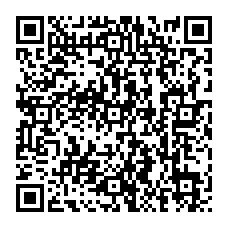

In [3]:
url = "https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/3_lenguaje_proposicional/clase_03_control_de_variables/clase_3_posibilidades_logicas.ipynb"
generar_qr(url) 

### [Video de apoyo a la lectura interactiva y experimental de este cuaderno]()

## [Vínculo al programa del curso Camino a La Universidad o PIVU:  ](https://github.com/marco-canas/camino-udea/blob/main/0_programa_curso_y_cronograma/programa_curso_pivu_caucasia.ipynb)

# Tema 3 Posibilidades Lógicas  



# Preguntas 1 a 2   

<img src = 'preguntas_1_y_2.jpeg'>

Para resolver los retos de lógica visual y transformación de estados en menos de 2 minutos, utilizaremos un enfoque de **codificación binaria y álgebra booleana**. Estos problemas (3.1 y 3.2) se basan en la aplicación de tres operadores lógicos sobre un modelo inicial.

---



### 1. Enunciado y Reglas del Sistema

Partimos de un **modelo inicial** compuesto por dos cuadrados: el de la izquierda es gris claro y el de la derecha es gris oscuro. Se definen tres reglas de transformación ($R_1, R_2, R_3$):

* **$R1$ (Inversión de Color):** Intercambia los colores de ambos lados. El claro pasa a ser oscuro y viceversa.
* **$R2$ (Diseño Derecha):** Cambia el cuadrado derecho por un triángulo rectángulo.
* **$R3$ (Diseño Izquierda):** Cambia el cuadrado izquierdo por un triángulo rectángulo.

**Notación de secuencia:** Una secuencia de 3 dígitos indica si se aplica (1) o no (0) cada regla en orden $(R1, R2, R3)$.

---



### 2. Estrategia de Resolución Rápida (< 2 min)

#### Problema 3.1: Determinar la secuencia para una forma dada
**Objetivo:** Llegar a una forma con dos triángulos enfrentados (diseño de "montaña") donde el izquierdo es claro y el derecho es oscuro.

1.  **Analizar Forma:** Hay triángulos en ambos lados $\rightarrow$ Debo aplicar $R2$ (1) y $R3$ (1).
2.  **Analizar Color:** El modelo resultante tiene el color original (izq claro, der oscuro) $\rightarrow$ No debo aplicar $R1$ (0).
3.  **Resultado:** Secuencia **011**.

**Respuesta Correcta: (b)**.



#### Problema 3.2: Determinar la forma para la secuencia 101
**Objetivo:** Aplicar la secuencia **101** al modelo inicial.

1.  **$R1 = 1$:** Invertir colores $\rightarrow$ Ahora el izquierdo es oscuro y el derecho es claro.
2.  **$R2 = 0$:** Mantener el cuadrado de la derecha.
3.  **$R3 = 1$:** Cambiar el lado izquierdo por un triángulo.
4.  **Resultado:** Un triángulo oscuro a la izquierda y un cuadrado claro a la derecha. Esto corresponde a la **forma IV**.

**Respuesta Correcta: (d)**.

---



### 3. Implementación Interactiva con Python

Utilizaremos **Matplotlib** para dibujar las formas y **ipywidgets** para crear un simulador en tiempo real.


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from IPython.display import display

def dibujar_modelo(secuencia="000"):
    r1, r2, r3 = [int(x) for x in secuencia]
    fig, ax = plt.subplots(figsize=(4, 2))
    
    # Definición de colores originales
    c_izq, c_der = '#D3D3D3', '#808080' # Claro, Oscuro
    if r1: c_izq, c_der = c_der, c_izq # Inversión por R1
    
    # Dibujar Lado Izquierdo (R3)
    if r3:
        # Triángulo
        poly = patches.Polygon([[0,0], [1,1], [1,0]], facecolor=c_izq, edgecolor='black')
    else:
        # Cuadrado
        poly = patches.Rectangle((0,0), 1, 1, facecolor=c_izq, edgecolor='black')
    ax.add_patch(poly)
    
    # Dibujar Lado Derecho (R2)
    if r2:
        # Triángulo
        poly = patches.Polygon([[1,0], [1,1], [2,0]], facecolor=c_der, edgecolor='black')
    else:
        # Cuadrado
        poly = patches.Rectangle((1,0), 1, 1, facecolor=c_der, edgecolor='black')
    ax.add_patch(poly)

    ax.set_xlim(0, 2); ax.set_ylim(0, 1); ax.axis('off')
    plt.title(f"Secuencia Aplicada: {secuencia}")
    plt.show()

# Interfaz interactiva
interactiva = widgets.SelectionSlider(
    options=['000', '010', '011', '101', '111'],
    value='000',
    description='Secuencia:',
    continuous_update=False
)

widgets.interact(dibujar_modelo, secuencia=interactiva)


interactive(children=(SelectionSlider(continuous_update=False, description='Secuencia:', options=('000', '010'…

<function __main__.dibujar_modelo(secuencia='000')>

### 4. Resumen Didáctico y Matemático

Podemos ver cada estado como un vector de propiedades $S = [C, D_I, D_D]$ donde $C \in \{0, 1\}$ es el estado del color y $D$ es el diseño. Los operadores actúan así:

$$f(S, secuencia) = \begin{cases} R1: C = \neg C & \text{si bit}_1 = 1 \\ R2: D_D = \text{Triángulo} & \text{si bit}_2 = 1 \\ R3: D_I = \text{Triángulo} & \text{si bit}_3 = 1 \end{cases}$$

**Estrategia Maestra:**
* **Separación de variables:** Resuelve primero la forma (geometría) y luego el color (inversión).
* **Deducción inversa:** Si la forma es compleja, mira qué reglas NO se aplicaron para descartar opciones rápidamente.

# Preguntas 3 y 4

<img src = 'preguntas_3_y_4.jpeg'>

Para resolver los problemas de rutas aéreas (Imagen `preguntas_3_y_4.jpeg`), utilizaremos un enfoque de **teoría de grafos** y **lógica proposicional**. El objetivo es traducir una tabla de adyacencia a un diagrama visual y evaluar la conectividad entre ciudades.



### 1. Enunciado y Reglas del Sistema

El cuadro muestra las rutas cubiertas por vuelos directos de una compañía aérea. La fila indica el **origen** y la columna el **destino**; el símbolo "si" indica vuelo directo y "x" la inexistencia del mismo.

**Rutas directas identificadas:**
* **Desde Medellín:** hacia Bogotá y hacia Pereira.
* **Desde Bogotá:** hacia Medellín.
* **Desde Cali:** hacia Medellín.
* **Desde Pereira:** hacia Cali.

Para recrear la tabla de doble entrada (matriz de adyacencia) que describe las rutas aéreas entre las ciudades, utilizaremos **Pandas**. 

Esta tabla es fundamental porque define el origen (filas) y el destino (columnas). El símbolo "si" representa la existencia de un vuelo directo, mientras que "x" representa la ausencia del mismo.

### Script de Pandas para la Tabla de Rutas


In [8]:
import pandas as pd

# 1. Definir los datos de la tabla de adyacencia
# Las llaves son las columnas (Destinos) y los valores siguen el orden de las filas (Orígenes)
data = {
    'Medellín': ['x', 'si', 'si', 'x'],
    'Bogotá':   ['si', 'x', 'x', 'x'],
    'Cali':     ['x', 'x', 'x', 'si'],
    'Pereira':  ['si', 'x', 'x', 'x']
}

# 2. Crear el DataFrame con los nombres de las ciudades como índices (Orígenes)
ciudades = ['Medellín', 'Bogotá', 'Cali', 'Pereira']
df_rutas = pd.DataFrame(data, index=ciudades)

# 3. Renombrar los ejes para claridad didáctica
df_rutas.index.name = 'ORIGEN \ DESTINO'

# 4. Mostrar la tabla
print("Tabla de Doble Entrada: Rutas Aéreas Directas")
display(df_rutas)


Tabla de Doble Entrada: Rutas Aéreas Directas


,Medellín,Bogotá,Cali,Pereira
ORIGEN \ DESTINO,,,,
Medellín,x,si,x,si
Bogotá,si,x,x,x
Cali,si,x,x,x
Pereira,x,x,si,x


### Explicación de la Tabla Resultante

Al ejecutar el código, obtendrás la siguiente matriz lógica basada fielmente en la imagen:

| **ORIGEN \ DESTINO** | **Medellín** | **Bogotá** | **Cali** | **Pereira** |
| :--- | :---: | :---: | :---: | :---: |
| **Medellín** | x | si | x | si |
| **Bogotá** | si | x | x | x |
| **Cali** | si | x | x | x |
| **Pereira** | x | x | si | x |



### Análisis de la Tabla para la Resolución
* **Fila Medellín:** Muestra que desde Medellín puedes ir directamente a Bogotá y Pereira.
* **Fila Pereira:** Solo tiene un "si" en la columna de Cali, lo que confirma que para ir a cualquier otra ciudad desde Pereira, primero debes pasar por Cali.
* **Conexión Pereira -> Bogotá:** Al observar la tabla, no hay un "si" directo entre ellos. Siguiendo los "si" disponibles: Pereira $\rightarrow$ Cali $\rightarrow$ Medellín $\rightarrow$ Bogotá. Esto demuestra por qué la opción (c) de la pregunta 3.4 es la falsa, ya que pasar por Medellín es un requisito obligatorio de la red, no una opción aleatoria.

Para representar las rutas aéreas del enunciado, utilizaremos un **Grafo Dirigido**. En este tipo de diagramas, los nodos son las ciudades y las flechas (aristas) indican la dirección permitida del vuelo según la tabla de adyacencia.

### Estructura de las Rutas (Diccionario de Adyacencia)
Basándonos en la tabla, las conexiones son:
* **Medellín:** Conecta con Bogotá y Pereira.
* **Bogotá:** Conecta con Medellín.
* **Cali:** Conecta con Medellín.
* **Pereira:** Conecta con Cali.

---

### Implementación con Matplotlib y NetworkX

Esta es la forma más estándar de generar grafos dentro de un entorno de Python como el que estás configurando.



```python
import networkx as nx
import matplotlib.pyplot as plt

# 1. Crear el objeto de grafo dirigido
G = nx.DiGraph()

# 2. Definir las rutas directas ("si" en la tabla)
rutas = [
    ('Medellín', 'Bogotá'),
    ('Medellín', 'Pereira'),
    ('Bogotá', 'Medellín'),
    ('Cali', 'Medellín'),
    ('Pereira', 'Cali')
]

G.add_edges_from(rutas)

# 3. Configurar el diseño visual
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # Posicionamiento de los nodos

# Dibujar nodos y etiquetas
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='skyblue', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=12, font_family='sans-serif', font_weight='bold')

# Dibujar flechas con curvatura para rutas de ida y vuelta (Medellín <-> Bogotá)
nx.draw_networkx_edges(
    G, pos, 
    edgelist=rutas, 
    width=2, 
    arrowstyle='->', 
    arrowsize=20, 
    edge_color='gray',
    connectionstyle='arc3,rad=0.1'  # Curva ligera para evitar solapamiento
)

plt.title("Grafo de Rutas Aéreas (Preguntas 3.3 - 3.4)", pad=20)
plt.axis('off')
plt.show()
```

---

### Análisis del Grafo para la Solución
Al observar el grafo generado, la resolución de las preguntas se vuelve trivial:

* **Pregunta 3.3:** El grafo resultante debe tener a **Medellín** como el nodo con más conexiones de salida (2) y a **Bogotá** y **Cali** con solo una conexión de salida hacia Medellín.
* **Pregunta 3.4:** Para ir de **Pereira a Bogotá**, el grafo muestra un único camino posible: $Pereira \rightarrow Cali \rightarrow Medellín \rightarrow Bogotá$. Como todos los caminos desde Pereira hacia Bogotá deben pasar por Medellín, cualquier afirmación que diga que se puede evitar Medellín es falsa.

### ¿Por qué usar Graphviz?
Si prefieres **Graphviz** (usando la librería `graphviz` en Python), el código es más compacto y el motor de renderizado es especializado en jerarquías:


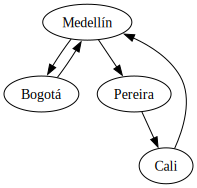

In [7]:
from graphviz import Digraph

dot = Digraph(comment='Rutas Aéreas')
dot.edge('Medellín', 'Bogotá')
dot.edge('Medellín', 'Pereira')
dot.edge('Bogotá', 'Medellín')
dot.edge('Cali', 'Medellín')
dot.edge('Pereira', 'Cali')

# dot.render('rutas_aereas', view=True) # Genera un PDF/Imagen
display(dot)


```


### 2. Estrategia de Resolución (< 2 minutos)

#### Problema 3.3: Identificar el gráfico correcto
1.  **Verificar origen Medellín:** Debe tener flechas saliendo hacia Bogotá y Pereira.
2.  **Verificar origen Pereira:** Solo debe tener una flecha hacia Cali.
3.  **Verificar origen Cali:** Solo debe tener una flecha hacia Medellín.
4.  **Verificar origen Bogotá:** Solo debe tener una flecha hacia Medellín.
5.  **Análisis:** Al observar las opciones, el gráfico **(a)** muestra exactamente estas conexiones: Medellín $\rightarrow$ Bogotá, Medellín $\rightarrow$ Pereira, Pereira $\rightarrow$ Cali, Cali $\rightarrow$ Medellín y Bogotá $\rightarrow$ Medellín.

**Respuesta Correcta: (a)**.

#### Problema 3.4: Identificar la opción FALSA
Analizamos la conexión entre **Pereira y Bogotá**:
1.  **Ruta posible:** Pereira $\rightarrow$ Cali $\rightarrow$ Medellín $\rightarrow$ Bogotá.
2.  **Evaluación de opciones:**
    * (a) *Si viaja de Pereira a Bogotá pasa por Medellín:* **Verdadero**, Medellín es el único que conecta con Bogotá.
    * (b) *Si no pasa por Medellín, no puede viajar de Pereira a Bogotá:* **Verdadero** (es el contrarecíproco de la anterior).
    * (c) *Si pasa por Medellín, entonces viaja entre Pereira y Bogotá:* **FALSO**. Pasar por Medellín no garantiza que el origen sea Pereira o el destino Bogotá (podría ir de Cali a Bogotá, por ejemplo).
    * (d) *Si viaja entre Pereira y Bogotá no usa vuelo directo:* **Verdadero**, no hay "si" en la celda Pereira-Bogotá.

**Respuesta Correcta (Falsa): (c)**.

---



### 3. Implementación Interactiva con Python

Utilizaremos **Pandas** para la tabla y un simulador de rutas con **ipywidgets**.



In [5]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Crear la tabla de rutas con Pandas
rutas_data = {
    'Medellín': ['x', 'si', 'x', 'si'],
    'Bogotá': ['si', 'x', 'x', 'x'],
    'Cali': ['si', 'x', 'x', 'x'],
    'Pereira': ['x', 'x', 'si', 'x']
}
df_rutas = pd.DataFrame(rutas_data, index=['Medellín', 'Bogotá', 'Cali', 'Pereira']).T

def verificador_ruta(origen, destino):
    print(f"Buscando conexión de {origen} a {destino}...")
    if df_rutas.loc[origen, destino] == 'si':
        print(f"✅ ¡Vuelo directo encontrado!")
    else:
        # Lógica de conexión simple para el ejemplo
        if origen == 'Pereira' and destino == 'Bogotá':
            print("✈️ Ruta con escalas: Pereira -> Cali -> Medellín -> Bogotá")
        else:
            print("❌ No hay ruta directa disponible.")

# Interfaz interactiva
widgets.interact(verificador_ruta, 
    origen=['Medellín', 'Bogotá', 'Cali', 'Pereira'],
    destino=['Medellín', 'Bogotá', 'Cali', 'Pereira']
)


interactive(children=(Dropdown(description='origen', options=('Medellín', 'Bogotá', 'Cali', 'Pereira'), value=…

<function __main__.verificador_ruta(origen, destino)>

### 4. Análisis Lógico Matemático

Podemos definir la conectividad como una relación $R$. La opción (c) del problema 3.4 comete la falacia de **afirmación del consecuente**.

Si definimos:
* $P$: Viajar de Pereira a Bogotá.
* $Q$: Pasar por Medellín.

La regla válida es $P \implies Q$. La opción (c) pretende que $Q \implies P$ sea cierto, lo cual es lógicamente inválido.

**Estrategia Maestra:**
* Para grafos, verifica siempre el "grado de salida" (cuántas flechas salen de cada nodo).
* En lógica, recuerda que "A implica B" no significa que "B implique A".

# Pregunta 5

<img src = 'pregunta_5.jpeg'>

# Pregunta 6

<img src = 'pregunta_6.jpeg'>

# Preguntas 7 a 11  

<img src = 'preguntas_7_a_11.jpeg'>

### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

## [Evaluación luego de alcanzar estos objetivos de aprendizaje]()

## Referentes 

* [stewart precálculo](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/ERHIq62I6qFNrmxy6LZb8ZMBci7kUsyNME1nIh9yCBMJ_w?e=0zMSla)  

* [stewart cálculo](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/EZgXZjAp8QxPqOAim2hs6LcBNPLGjSHf-xwYnUVYkwa04w?e=RZdTCy)  

* [larson](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/ES71ChFeO9ZDhW3TwC5Ijk8BjxUK3Pdqz_fjHxTTFAfIAg?e=VDEjfu)

* [uzcategui](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/ETDikm-lVl1Or8XoEo9oyh0BEti9Zs8le-f0D-dBdtZmbA?e=bBsoyQ)

* [Cálculo de Purcell](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/ES60UB4h-QFFqqRQUFmkpWcBIgoLBJeqTfZjNajWNWSeJA?e=9NxjKJ)

* [Recomendación de la UNESCO sobre ciencia abierta](https://unesdoc.unesco.org/ark:/48223/pf0000379949_spa)

* [Geron, Aurelien. Hands on Machine Learning](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/Ecet27yjQzZIlT1Y_Bc2erkBUhbeYuIe6HG8i1FYZRlZww?e=gaOjqk)

* [McKinney, West. Python for data Analysis.](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/EVbi5JIeBl9ErbiUnZfGe8YBhNTnZ8sxTK5hjIOPK4UpGw?e=tfkShe)



### Continue su aprendizaje en la siguiente clase a través del siguiente [vínculo]()

# Conjeturas pedagógicas fruto de la aplicación del modelo de aprendizaje invertido y del enfoque hacia la ciencia de datos con python

1. Todo cálculo o resultado debe ser interpretado en una línea markdown del cuaderno Jupyter, inmediatamente después de la enunciación del resultado y después de la presentación de una tabla o gráfico bidimensional, de tal menera que el estudiante explicite la comprensión verbal del resultado y las inferencias o estrategias que este resultado le sugieren.   

## Agradecimientos  

Doy gracias a Dios por la vida de mi Hijo Joseph Cañas Osorio y la madurez que ha alcanzado.

Y a mi esposa Yasmira por su apoyo, orientación y acompañamiento. 

# Desarrollo de competencias en Python y ciencia de datos

## [West McKinney. Python for data Analysis](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/EVbi5JIeBl9ErbiUnZfGe8YBhNTnZ8sxTK5hjIOPK4UpGw?e=tfkShe)

### CHAPTER 2  
#### Python Language Basics, IPython, and Jupyter Notebooks  



When I wrote the first edition of this book in 2011 and 2012, there were fewer resources available for learning about doing data analysis in Python. This was partially a chicken-and-egg problem; many libraries that we now take for granted, like pandas,
scikit-learn, and statsmodels, were comparatively immature back then. In 2017, there is now a growing literature on data science, data analysis, and machine learning, supplementing the prior works on general-purpose scientific computing geared toward computational scientists, physicists, and professionals in other research fields. There are also excellent books about learning the Python programming language itself and becoming an effective software engineer. As this book is intended as an introductory text in working with data in Python, I feel it is valuable to have a self-contained overview of some of the most important features of Python’s built-in data structures and libraries from the perspective of data manipulation. So, I will only present roughly enough information in this chapter and Chapter 3 to enable you to follow along with the rest of the book.
In my opinion, it is not necessary to become proficient at building good software in Python to be able to productively do data analysis. I encourage you to use the IPython shell and Jupyter notebooks to experiment with the code examples and to
explore the documentation for the various types, functions, and methods. While I’ve made best efforts to present the book material in an incremental form, you may occasionally encounter things that have not yet been fully introduced.
Much of this book focuses on table-based analytics and data preparation tools for working with large datasets. In order to use those tools you must often first do some munging to corral messy data into a more nicely tabular (or structured) form. Fortu‐
nately, Python is an ideal language for rapidly whipping your data into shape. The greater your facility with Python the language, the easier it will be for you to prepare new datasets for analysis. Some of the tools in this book are best explored from a live IPython or Jupyter session. Once you learn how to start up IPython and Jupyter, I recommend that you follow along with the examples so you can experiment and try different things. As with any keyboard-driven console-like environment, developing muscle-memory for the common commands is also part of the learning curve. There are introductory Python concepts that this chapter does not cover, like classes and object-oriented programming, which you may find useful in your foray into data analysis in Python. To deepen your Python language knowledge, I recommend that you supplement this chapter with the official Python tutorial and potentially one of the many excellent books on general-purpose Python programming. Some recommendations to get you started include:  

* Python Cookbook, Third Edition, by David Beazley and Brian K. Jones (O’Reilly)
* Fluent Python by Luciano Ramalho (O’Reilly)
* Effective Python by Brett Slatkin (Pearson)

# [Geron. Hand on Neuronal Networks]()

Página 279 del libro. Segunda edición.

## Chapter 10. Introduction to Artificial Neural Networks with Keras  

### Implementing MLPs with Keras

Keras is a high-level Deep Learning API that allows you to easily build, train, evaluate, and execute all sorts of neural networks. Its documentation (or specification) is available at https://keras.io/. The reference implementation, also called Keras, was developed by François Chollet as part of a research project and was released as an open source project in
March 2015. It quickly gained popularity, owing to its ease of use, flexibility, and beautiful design. To perform the heavy computations required by neural networks, this reference implementation relies on a computation backend. At present, you can choose from three popular open source Deep Learning libraries: TensorFlow, Microsoft Cognitive Toolkit(CNTK), and Theano. Therefore, to avoid any confusion, we will refer to this reference implementation as multibackend Keras. Since late 2016, other implementations have been released. You can now run Keras on Apache MXNet, Apple’s Core ML, JavaScript or TypeScript (to run Keras code in a web browser), and PlaidML (which can run on all sorts of GPU devices, not just Nvidia). Moreover, TensorFlow itself now comes bundled with its own Keras implementation, tf.keras. It only supports TensorFlow as the backend, but it has the advantage of offering some very useful extra features (see Figure 10-10): for example, it supports TensorFlow’s Data API, which makes it easy to load and preprocess data efficiently. For this reason, we will use tf.keras in this book. However, in this chapter we will not use any of the TensorFlow-specific features, so the code should run fine on other Keras implementations as well (at least in Python), with only minor modifications, such as changing the imports.

<img src = 'https://github.com/marco-canas/7_didactica_ciencia_datos/blob/main/referentes/geron/part_2/c_10/images/fig_10_10.png?raw=true'>

The most popular Deep Learning library, after Keras and TensorFlow, is
Facebook’s PyTorch library. The good news is that its API is quite similar
to Keras’s (in part because both APIs were inspired by Scikit-Learn and
Chainer), so once you know Keras, it is not difficult to switch to PyTorch, if
you ever want to. PyTorch’s popularity grew exponentially in 2018, largely
thanks to its simplicity and excellent documentation, which were not
TensorFlow 1.x’s main strengths. However, TensorFlow 2 is arguably just
as simple as PyTorch, as it has adopted Keras as its official high-level API
and its developers have greatly simplified and cleaned up the rest of the
API. The documentation has also been completely reorganized, and it is
much easier to find what you need now. Similarly, PyTorch’s main
weaknesses (e.g., limited portability and no computation graph analysis)
have been largely addressed in PyTorch 1.0. Healthy competition is
beneficial to everyone.
All right, it’s time to code! As tf.keras is bundled with TensorFlow, let’s
start by installing TensorFlow.
Installing TensorFlow 2
Assuming you installed Jupyter and Scikit-Learn by following the
installation instructions in Chapter 2, use pip to install TensorFlow. If you
created an isolated environment using virtualenv, you first need to activate
it:
$ cd $ML_PATH # Your ML working directory (e.g., $HOME/ml)
$ source my_env/bin/activate # on Linux or macOS
$ .\my_env\Scripts\activate # on Windows
Next, install TensorFlow 2 (if you are not using a virtualenv, you will need
administrator rights, or to add the --user option):
$ python3 -m pip install --upgrade tensorflow

### NOTE

For GPU support, at the time of this writing you need to install tensorflow-gpu instead of tensorflow, but the TensorFlow team is working on having a single library that will
support both CPU-only and GPU-equipped systems. You will still need to install extra
libraries for GPU support (see https://tensorflow.org/install for more details). We will
look at GPUs in more depth in Chapter 19.
To test your installation, open a Python shell or a Jupyter notebook, then
import TensorFlow and tf.keras and print their versions:

In [1]:
import tensorflow as tf 